In [2]:
# %pip install onnx2tf
# %pip install onnxscript onnx

In [1]:
import json
import os

import matplotlib.pyplot as plt
import numpy as np


import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import onnx2tf

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BASE_DIR = "drive/MyDrive/Dev Team Project 2026/"
ARTIFACTS_DIR = os.path.join(BASE_DIR, "artifacts")
DATASET_PATH = os.path.join(ARTIFACTS_DIR, "lstm_dataset.npz")
META_PATH = os.path.join(ARTIFACTS_DIR, "lstm_dataset_meta.json")

print(f"Device: {DEVICE}")
print(f"Artifacts dir: {ARTIFACTS_DIR}")

Device: cuda
Artifacts dir: drive/MyDrive/Dev Team Project 2026/artifacts


In [4]:
print(os.listdir(ARTIFACTS_DIR))
print(DATASET_PATH)
print(META_PATH)

['lstm_dataset.npz', 'lstm_dataset_meta.json', 'tf_model_dir', 'lstm_model.pth', 'model.onnx']
drive/MyDrive/Dev Team Project 2026/artifacts/lstm_dataset.npz
drive/MyDrive/Dev Team Project 2026/artifacts/lstm_dataset_meta.json


In [5]:
data = np.load(DATASET_PATH, allow_pickle=True)
with open(META_PATH, "r", encoding="utf-8") as f:
    meta = json.load(f)

print("Keys:", data.files)
for key in data.files:
    print(f"{key}: shape={data[key].shape}, dtype={data[key].dtype}")
print("Classes:", meta["class_names"])
print("Feature count:", meta["num_features"])

# Update seq_len to reflect the extended sequence length
meta["seq_len"] = 30

Keys: ['X_train_lstm', 'X_val_lstm', 'y_train_lstm', 'y_val_lstm']
X_train_lstm: shape=(1576, 10, 126), dtype=float32
X_val_lstm: shape=(395, 10, 126), dtype=float32
y_train_lstm: shape=(1576,), dtype=int64
y_val_lstm: shape=(395,), dtype=int64
Classes: ['3aslema', '3ayla', '5adamet', '5al-3am', '5mis', '5ou', 'a7ad', 'assam', 'baladya', 'banka', 'barnamjk', 'bent', 'bou', 'bousta', 'car', 'chabeb', 'cv', 'dar', 'demande', 'eben', 'enti', 'erb3a', 'jad', 'jadda', 'jom3a', 'karhba', 'labes', 'louage', 'lyoum', 'ma7kma', 'mar2a', 'mar7ba', 'metro', 'mostawsaf', 'n3awnek', 'nekteblk', 'non', 'o5t', 'om', 'oui', 'radio', 'sbitar', 'se7a', 'sebt', 'siye7a', 't7eb', 'ta3lim', 'ta3raf', 'ta9ra', 'taxi', 'telvza', 'tfol', 'tha9afa', 'thleth', 'thnin', 'train', 'wzara']
Feature count: 126


In [6]:
X_train_lstm = data["X_train_lstm"]
X_val_lstm = data["X_val_lstm"]
y_train_lstm = data["y_train_lstm"]
y_val_lstm = data["y_val_lstm"]

num_classes = int(meta["num_classes"] )
seq_len = int(meta["seq_len"] )
num_features = int(meta["num_features"] )

print("Train shape:", X_train_lstm.shape, y_train_lstm.shape)
print("Val shape:", X_val_lstm.shape, y_val_lstm.shape)
print("Sequence length:", seq_len)
print("Feature count:", num_features)
print("Class count:", num_classes)

Train shape: (1576, 10, 126) (1576,)
Val shape: (395, 10, 126) (395,)
Sequence length: 30
Feature count: 126
Class count: 57


In [7]:
def extend_sequences(X, target_frames=30):
    """
    Extend sequences from seq_len to target_frames using linear interpolation.
    
    Args:
        X: array of shape (num_samples, seq_len, num_features)
        target_frames: desired number of frames (default 30)
    
    Returns:
        X_extended: array of shape (num_samples, target_frames, num_features)
    """
    num_samples, seq_len, num_features = X.shape
    X_extended = np.zeros((num_samples, target_frames, num_features), dtype=X.dtype)
    
    # Create indices for original frames (0 to seq_len-1)
    original_indices = np.linspace(0, seq_len - 1, seq_len)
    # Create indices for extended frames (0 to seq_len-1, stretched to 30 frames)
    new_indices = np.linspace(0, seq_len - 1, target_frames)
    
    for i in range(num_samples):
        for f in range(num_features):
            # Linear interpolation for each feature
            X_extended[i, :, f] = np.interp(new_indices, original_indices, X[i, :, f])
    
    return X_extended

# Extend sequences from 10 to 30 frames
X_train_lstm = extend_sequences(X_train_lstm, target_frames=30)
X_val_lstm = extend_sequences(X_val_lstm, target_frames=30)

print(f"Extended X_train_lstm shape: {X_train_lstm.shape}")
print(f"Extended X_val_lstm shape: {X_val_lstm.shape}")

Extended X_train_lstm shape: (1576, 30, 126)
Extended X_val_lstm shape: (395, 30, 126)


In [8]:
num_classes = int(meta["num_classes"] )
seq_len = int(meta["seq_len"] )
num_features = int(meta["num_features"] )

print("Train shape:", X_train_lstm.shape, y_train_lstm.shape)
print("Val shape:", X_val_lstm.shape, y_val_lstm.shape)
print("Sequence length:", seq_len)
print("Feature count:", num_features)
print("Class count:", num_classes)

Train shape: (1576, 30, 126) (1576,)
Val shape: (395, 30, 126) (395,)
Sequence length: 30
Feature count: 126
Class count: 57


In [9]:
X_train_tensor = torch.tensor(X_train_lstm, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_lstm, dtype=torch.long)
X_val_tensor = torch.tensor(X_val_lstm, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val_lstm, dtype=torch.long)

train_loader = DataLoader(
    TensorDataset(X_train_tensor, y_train_tensor),
    batch_size=64,
    shuffle=True,
    drop_last=False,
)
val_loader = DataLoader(
    TensorDataset(X_val_tensor, y_val_tensor),
    batch_size=64,
    shuffle=False,
)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Input tensor shape: {X_train_tensor.shape}")

Train batches: 25
Val batches: 7
Input tensor shape: torch.Size([1576, 30, 126])


In [10]:
class LSTMHybrid(nn.Module):
    def __init__(self, input_size: int, hidden_sizes: tuple, dense_sizes: tuple, num_classes: int, dropout: float = 0.3):
        super().__init__()

        h1, h2, h3 = hidden_sizes
        d1, d2 = dense_sizes

        self.lstm1 = nn.LSTM(
            input_size=input_size,
            hidden_size=h1,
            batch_first=True,
        )

        self.lstm2 = nn.LSTM(
            input_size=h1,
            hidden_size=h2,
            batch_first=True,
        )

        self.lstm3 = nn.LSTM(
            input_size=h2,
            hidden_size=h3,
            batch_first=True,
        )

        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(h3, d1)
        self.fc2 = nn.Linear(d1, d2)
        self.fc3 = nn.Linear(d2, num_classes)
        self.relu = nn.ReLU()

    def forward(self, x):
        x, _ = self.lstm1(x)
        x, _ = self.lstm2(x)
        x, _ = self.lstm3(x)

        x = x[:, -1, :]

        x = self.relu(self.fc1(x))
        x = self.dropout(x)

        x = self.relu(self.fc2(x))
        x = self.dropout(x)

        return self.fc3(x)


model = LSTMHybrid(
    input_size=num_features,
    hidden_sizes=(64, 128, 128),
    dense_sizes=(64, 32),
    num_classes=num_classes,
    dropout=0.3,
).to(DEVICE)

print(model)

LSTMHybrid(
  (lstm1): LSTM(126, 64, batch_first=True)
  (lstm2): LSTM(64, 128, batch_first=True)
  (lstm3): LSTM(128, 128, batch_first=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=128, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=57, bias=True)
  (relu): ReLU()
)


In [11]:
def accuracy_from_logits(logits, targets):
    predictions = torch.argmax(logits, dim=1)
    return (predictions == targets).float().mean().item()

def run_epoch(model, loader, criterion, optimizer=None):
    is_training = optimizer is not None
    model.train() if is_training else model.eval()

    total_loss = 0.0
    total_correct = 0
    total_items = 0

    for batch_inputs, batch_targets in loader:
        batch_inputs = batch_inputs.to(DEVICE)
        batch_targets = batch_targets.to(DEVICE)

        if is_training:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_training):
            logits = model(batch_inputs)
            loss = criterion(logits, batch_targets)
            if is_training:
                loss.backward()
                optimizer.step()

        batch_size = batch_targets.size(0)
        total_loss += loss.item() * batch_size
        total_correct += (torch.argmax(logits, dim=1) == batch_targets).sum().item()
        total_items += batch_size

    return total_loss / total_items, total_correct / total_items

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
}

In [14]:
num_epochs = 100
best_val_acc = 0.0
best_state = None

for epoch in range(1, num_epochs + 1):
    train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = run_epoch(model, val_loader, criterion)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}

    print(
        f"Epoch {epoch:02d}/{num_epochs} | "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}"
    )

if best_state is not None:
    model.load_state_dict(best_state)

print(f"Best val accuracy: {best_val_acc:.4f}")

Epoch 01/100 | train_loss=1.1902 train_acc=0.5501 | val_loss=1.0874 val_acc=0.6405
Epoch 02/100 | train_loss=1.1424 train_acc=0.5698 | val_loss=0.9974 val_acc=0.6557
Epoch 03/100 | train_loss=1.1178 train_acc=0.5939 | val_loss=0.9105 val_acc=0.6937
Epoch 04/100 | train_loss=1.0715 train_acc=0.6028 | val_loss=0.9399 val_acc=0.6861
Epoch 05/100 | train_loss=1.0680 train_acc=0.6104 | val_loss=0.9450 val_acc=0.6937
Epoch 06/100 | train_loss=1.0765 train_acc=0.6053 | val_loss=0.9459 val_acc=0.6810
Epoch 07/100 | train_loss=1.0316 train_acc=0.6085 | val_loss=0.8747 val_acc=0.7063
Epoch 08/100 | train_loss=0.9864 train_acc=0.6218 | val_loss=0.8838 val_acc=0.7215
Epoch 09/100 | train_loss=0.9538 train_acc=0.6402 | val_loss=0.9474 val_acc=0.6987
Epoch 10/100 | train_loss=1.0184 train_acc=0.6256 | val_loss=0.8955 val_acc=0.6987
Epoch 11/100 | train_loss=0.9730 train_acc=0.6212 | val_loss=0.8256 val_acc=0.7089
Epoch 12/100 | train_loss=0.9396 train_acc=0.6313 | val_loss=0.9192 val_acc=0.7013
Epoc

Validation predictions sample: [32 12 48 10 12  9 56 11 30 53 36 19 13 26 37 40 12 28 15 11]


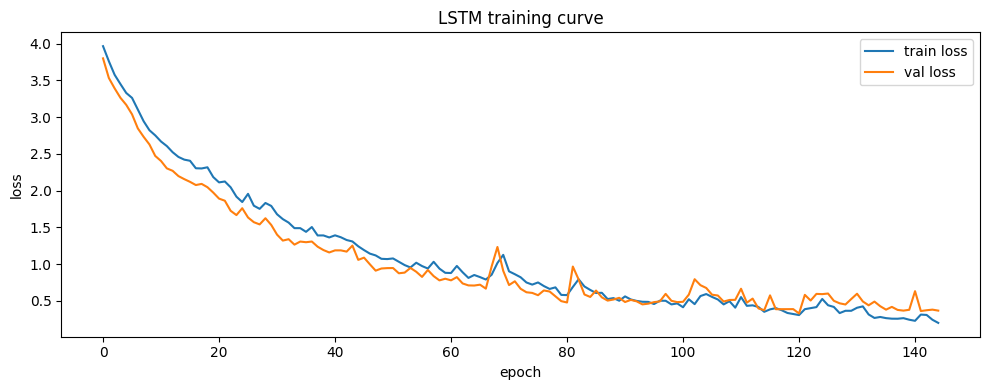

In [15]:
model.eval()
with torch.no_grad():
    val_logits = model(X_val_tensor.to(DEVICE))
    val_predictions = torch.argmax(val_logits, dim=1).cpu().numpy()

print("Validation predictions sample:", val_predictions[:20])

plt.figure(figsize=(10, 4))
plt.plot(history["train_loss"], label="train loss")
plt.plot(history["val_loss"], label="val loss")
plt.title("LSTM training curve")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.tight_layout()
plt.show()

In [16]:
# save the model
model_path = os.path.join(ARTIFACTS_DIR, "lstmhybrid_model.pth")
torch.save(model.state_dict(), model_path)
print(f"Model saved to: {model_path}")

Model saved to: drive/MyDrive/Dev Team Project 2026/artifacts/lstmhybrid_model.pth


In [17]:
# model_path = os.path.join(ARTIFACTS_DIR, "lstm_model.pth")
# model.load_state_dict(torch.load(model_path, map_location=DEVICE))
# model.to(DEVICE)
# model.eval()

# print(f"Model loaded on {DEVICE}")
# print(f"seq_len={seq_len}, num_features={num_features}, num_classes={num_classes}")

In [17]:
model.eval()
model.cpu() 

sample_input = torch.randn(1, seq_len, num_features)

torch.onnx.export(
    model,
    sample_input,
    os.path.join(ARTIFACTS_DIR, "model.onnx"),
    input_names=["input"],
    output_names=["output"],
    dynamic_axes={
        "input": {0: "batch_size"},  
        "output": {0: "batch_size"}
    },
    opset_version=12,  
    dynamo=False
)
print("ONNX export done")

/tmp/ipykernel_8715/3973855739.py:6: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(
/usr/local/lib/python3.12/dist-packages/torch/onnx/_internal/torchscript_exporter/symbolic_opset9.py:4445: UserWarning: Exporting a model to ONNX with a batch_size other than 1, with a variable length with LSTM can cause an error when running the ONNX model with a different batch size. Make sure to save the model with a batch size of 1, or define the initial states (h0/c0) as inputs of the model. 
  return _generic_rnn(


ONNX export done


In [18]:
onnx2tf.convert(
    input_onnx_file_path=os.path.join(ARTIFACTS_DIR, "model.onnx"),
    output_folder_path=os.path.join(ARTIFACTS_DIR, "tf_model_dir", "lstmhybrid"),
    non_verbose=True,
)
print("TF SavedModel export done")

flatbuffer_direct lowering:   0%|          | 0/31 [00:00<?, ?it/s]

flatbuffer_direct post-lowering:   0%|          | 0/6 [00:00<?, ?it/s]

flatbuffer_direct export:   0%|          | 0/3 [00:00<?, ?it/s]

flatbuffer_direct write timing: stage=float32 mode=builder_direct total=0.562s serialize=0.008s (sanitize=0.000s build=0.001s pack=0.006s output=0.000s) write=0.550s size=1.12MB
flatbuffer_direct write timing: stage=float16 mode=builder_direct total=0.551s serialize=0.007s (sanitize=0.000s build=0.001s pack=0.006s output=0.000s) write=0.542s size=0.57MB
TF SavedModel export done


In [ ]:
TF_MODEL_DIR = os.path.join(ARTIFACTS_DIR, "tf_model_dir", "lstmhybrid")
for root, dirs, files in os.walk(TF_MODEL_DIR):
    level = root.replace(TF_MODEL_DIR, "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")
    for file in files:
        filepath = os.path.join(root, file)
        size_kb = os.path.getsize(filepath) / 1024
        print(f"{indent}  {file} ({size_kb:.1f} KB)")